In [439]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [440]:
import sys
sys.path.append('/content/drive/MyDrive/optimized_kan')


In [441]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
kan_model = KAN(width=[5, 5,1], grid=5, k=3, seed=42, device=device)
mpkan_model = MPKAN(width=[5, 5,1], grid=5, k=3, seed=42, device=device)
compiled_kan_model = KAN(width=[5, 5,1], grid=5, k=3, seed=42, device=device).speed(compile=True)
compiled_mpkan_model = MPKAN(width=[5, 5,1], grid=5, k=3, seed=42, device=device).speed(compile=True)
compiled_opt_kan_model = KAN(width=[5,5,1], grid=5, k=3, seed=42, device=device).speed(compile=True, dynamic=False, fullgraph=True, options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})
compiled_opt_mpkan_model = MPKAN(width=[5,5,1], grid=5, k=3, seed=42, device=device).speed(compile=True, dynamic=False, fullgraph=True, options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})

cuda
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [442]:
from kan.utils import create_dataset
from torch.distributions.normal import Normal

eps = 1e-6

# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: (
    x[:, [0]].clamp(min=eps) * Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] + 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    ) -
    x[:, [1]].clamp(min=eps) * torch.exp(-x[:, [3]] * x[:, [2]]) *
    Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] - 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    )
)
input_size = 100
dataset = create_dataset(f, n_var=5, train_num=input_size, test_num=input_size, device=device)
batch_size = -1
steps = 100
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([100, 5]), torch.Size([100, 1]))

Plot KAN at initialization

In [443]:
# plot KAN at initialization
kan_model(dataset['train_input']);
# kan_model.plot()

# plot MPKAN at initialization
mpkan_model(dataset['train_input']);
# mpkan_model.plot()

Train KAN with sparsity regularization

In [444]:
# train the kan_model
kan_metrics = kan_model.fit(dataset, opt="Adam", steps=steps, lamb=0.001, batch=batch_size, profile=True)

| train_loss: 7.03e-02 | test_loss: 1.03e-01 | reg: 4.52e+01 | : 100%|█| 100/100 [00:02<00:00, 34.93


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      64.238ms       440.03%      64.238ms      21.413ms           0 b           0 b           0 b           0 

In [445]:
mpkan_metrics = mpkan_model.fit(dataset, opt="Adam", steps=steps, lamb=0.001,  batch=batch_size, profile=True)

description:   0%|                                                          | 0/100 [00:00<?, ?it/s]/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(opt == "Adam"))
/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
| train_loss: 7.03e-02 | test_loss: 1.03e-01 | reg: 4.52e+01 | : 100%|█| 100/100 [00:02<00:00, 40.11


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      98.226ms       666.47%      98.226ms      32.742ms           0 b           0 b           0 b           0 

In [446]:
compiled_kan_metrics = compiled_kan_model.fit(dataset, opt="Adam", steps=steps, lamb=0.001,  batch=batch_size, profile=True)

setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 3.98e-02 | test_loss: 1.07e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [00:02<00:00, 41.61


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      51.249ms       734.24%      51.249ms      17.083ms           0 b           0 b           0 b           0 

In [447]:
compiled_mpkan_metrics = compiled_mpkan_model.fit(dataset, opt="Adam", steps=steps, lamb=0.001,  batch=batch_size, profile=True)

setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 3.98e-02 | test_loss: 1.07e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [00:02<00:00, 47.98


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     114.463ms      1611.23%     114.463ms      38.154ms           0 b           0 b           0 b           0 

In [448]:
compiled_opt_kan_metrics = compiled_opt_kan_model.fit(dataset, opt="Adam", steps=steps, lamb=0.001,  batch=batch_size, profile=True)

setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 3.98e-02 | test_loss: 1.07e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [00:01<00:00, 54.63


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      46.879ms       671.50%      46.879ms      15.626ms           0 b           0 b           0 b           0 

In [449]:
compiled_opt_mpkan_metrics = compiled_opt_mpkan_model.fit(dataset, opt="Adam", steps=steps, lamb=0.001,  batch=batch_size, profile=True)

setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 3.98e-02 | test_loss: 1.07e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [00:01<00:00, 52.79


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      70.212ms       987.96%      70.212ms      23.404ms           0 b           0 b           0 b           0 

In [450]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import *

class SplineLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, init_scale: float = 0.1, **kw) -> None:
        self.init_scale = init_scale
        super().__init__(in_features, out_features, bias=False, **kw)

    def reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.weight, mean=0, std=self.init_scale)

class RadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        grid = torch.linspace(grid_min, grid_max, num_grids)
        self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)

class FastKANLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y


class FastKAN(nn.Module):
    def __init__(
        self,
        layers_hidden: List[int],
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
        use_layernorm = False,
    ) -> None:
        super().__init__()
        self.layers = nn.ModuleList([
            FastKANLayer(
                in_dim, out_dim,
                grid_min=grid_min,
                grid_max=grid_max,
                num_grids=num_grids,
                use_base_update=use_base_update,
                base_activation=base_activation,
                spline_weight_init_scale=spline_weight_init_scale,
                use_layernorm=use_layernorm,
            ) for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:])
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x



    def fit(self, dataset, opt="LBFGS", steps=100, log=1, lamb=0.1,
        loss_fn=None, lr=1.0, batch=-1, metrics=None, profile=False):
        '''
        Training function for FastKAN

        Args:
            dataset (dict): Contains 'train_input', 'train_label', 'test_input', 'test_label'
            opt (str): Optimizer ('Adam' or 'LBFGS')
            steps (int): Number of training steps
            log (int): Logging frequency
            lamb (float): L2 regularization strength
            loss_fn (callable): Custom loss function (default: MSELoss)
            lr (float): Learning rate
            batch (int): Batch size (-1 for full batch)
            metrics (list): List of metric functions
            profile (bool): Enable profiling
        '''

        # Initialize loss and optimizer
        device = next(self.parameters()).device
        loss_fn = loss_fn or nn.MSELoss()

        if opt == "Adam":
            optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=lamb)
        elif opt == "LBFGS":
            optimizer = torch.optim.LBFGS(self.parameters(), lr=lr, history_size=10,
                                        line_search_fn="strong_wolfe")

        pbar = tqdm(range(steps), desc='description', ncols=100)

        # Profiling setup
        if profile:
            prof = torch.profiler.profile(
                activities=[
                    torch.profiler.ProfilerActivity.CPU,
                    torch.profiler.ProfilerActivity.CUDA,
                ],
                schedule=torch.profiler.schedule(
                    wait=1,
                    warmup=1,
                    active=3,
                    repeat=1),
                on_trace_ready=torch.profiler.tensorboard_trace_handler('./profile_logs'),
                record_shapes=True,
                with_stack=True,
                profile_memory=True
            )
            prof.start()

        # Batch handling
        batch_size = batch if batch > 0 else dataset['train_input'].shape[0]
        results = {'train_loss': [], 'test_loss': []}
        if metrics:
            for metric in metrics:
                results[metric.__name__] = []

        def closure():
            optimizer.zero_grad()
            pred = self(dataset['train_input'][train_idx].to(device))
            loss = loss_fn(pred, dataset['train_label'][train_idx].to(device))
            if lamb > 0:
                loss += lamb * sum(p.pow(2).sum() for p in self.parameters())
            loss.backward()
            return loss

        for _ in pbar:
            # Batch selection
            train_idx = torch.randperm(dataset['train_input'].shape[0])[:batch_size]

            # Optimization step
            if opt == "LBFGS":
                optimizer.step(closure)
            else:  # Adam
                loss = closure()
                optimizer.step()

            # Profiling
            if profile:
                prof.step()

            # Logging
            if _ % log == 0:
                with torch.no_grad():
                    test_pred = self(dataset['test_input'].to(device))
                    test_loss = loss_fn(test_pred, dataset['test_label'].to(device))

                results['train_loss'].append(torch.sqrt(loss).cpu().detach().numpy())
                results['test_loss'].append(torch.sqrt(test_loss).cpu().detach().numpy())

                if metrics:
                    for metric in metrics:
                        results[metric.__name__].append(
                            metric(test_pred, dataset['test_label'].to(device)).item()
                        )

                pbar.set_description("| train_loss: %.2e | test_loss: %.2e | " % (torch.sqrt(loss).cpu().detach().numpy(), torch.sqrt(test_loss).cpu().detach().numpy()))

        if profile:
            prof.stop()
            print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

        return results




In [451]:
model = FastKAN(layers_hidden=[5,5,1], grid_min=-1, grid_max=1)
fastkan_metrics = model.fit(dataset, opt="Adam", batch=batch_size, steps=steps, profile=True)

| train_loss: 1.48e+00 | test_loss: 4.14e-01 | : 100%|███████████| 100/100 [00:00<00:00, 164.28it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      14.030ms     19767.86%      14.030ms       4.677ms           0 b           0 b           0 b           0 

In [452]:
model = torch.compile(FastKAN(layers_hidden=[5,5,1], grid_min=-1, grid_max=1))
compiled_fastkan_metrics = model.fit(dataset, opt="Adam", batch=batch_size, steps=steps, profile=True)

| train_loss: 1.81e+00 | test_loss: 6.42e-01 | : 100%|███████████| 100/100 [00:00<00:00, 174.23it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      13.472ms     19041.86%      13.472ms       4.491ms           0 b           0 b           0 b           0 

In [453]:
model = torch.compile(FastKAN(layers_hidden=[5,5,1], grid_min=-1, grid_max=1),  dynamic=False, fullgraph=True, options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})
compiled_opt_fastkan_metrics = model.fit(dataset, opt="Adam", batch=batch_size, steps=steps, profile=True)

| train_loss: 1.37e+00 | test_loss: 9.79e-01 | : 100%|███████████| 100/100 [00:00<00:00, 123.88it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      17.423ms     24526.25%      17.423ms       5.808ms           0 b           0 b           0 b           0 

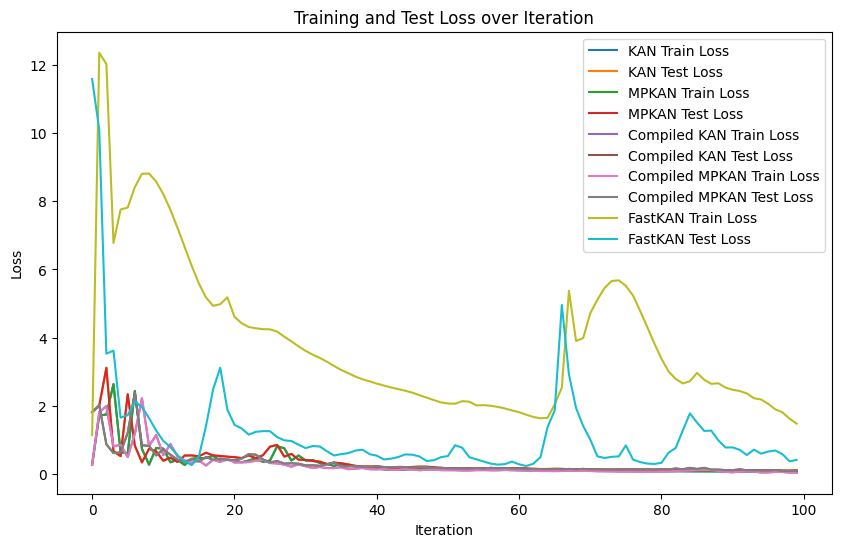

In [454]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.plot(np.array(kan_metrics['train_loss']), label='KAN Train Loss')
plt.plot(np.array(kan_metrics['test_loss']), label='KAN Test Loss')
plt.plot(np.array(mpkan_metrics['train_loss']), label='MPKAN Train Loss')
plt.plot(np.array(mpkan_metrics['test_loss']), label='MPKAN Test Loss')
plt.plot(np.array(compiled_kan_metrics['train_loss']), label='Compiled KAN Train Loss')
plt.plot(np.array(compiled_kan_metrics['test_loss']), label='Compiled KAN Test Loss')
plt.plot(np.array(compiled_mpkan_metrics['train_loss']), label='Compiled MPKAN Train Loss')
plt.plot(np.array(compiled_mpkan_metrics['test_loss']), label='Compiled MPKAN Test Loss')

plt.plot(np.array(fastkan_metrics['train_loss']), label='FastKAN Train Loss')
plt.plot(np.array(fastkan_metrics['test_loss']), label='FastKAN Test Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Iteration')
plt.legend()  # No arguments needed; uses the labels above
plt.show()
